<a href="https://colab.research.google.com/github/vinipi/flight_delay_prediction/blob/main/poc_flight_delay_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn

load the csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

CSV_PATH = "bts_jan.csv"

df = pd.read_csv(CSV_PATH)

print("Raw shape:", df.shape)
print(df.head())
print(df.dtypes)

/tmp/ipykernel_3122/1376630608.py:22: DtypeWarning: Columns (76: Div1TailNum, 77: Div2Airport, 84: Div2TailNum) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


Raw shape: (539747, 110)
   Year  Quarter  Month  DayofMonth  DayOfWeek  FlightDate Reporting_Airline  \
0  2025        1      1           1          3  2025-01-01                AA   
1  2025        1      1           2          4  2025-01-02                AA   
2  2025        1      1           3          5  2025-01-03                AA   
3  2025        1      1           4          6  2025-01-04                AA   
4  2025        1      1           5          7  2025-01-05                AA   

   DOT_ID_Reporting_Airline IATA_CODE_Reporting_Airline Tail_Number  ...  \
0                     19805                          AA      N104NN  ...   
1                     19805                          AA      N110AN  ...   
2                     19805                          AA      N106NN  ...   
3                     19805                          AA      N117AN  ...   
4                     19805                          AA      N104NN  ...   

   Div4TailNum  Div5Airport  Div5Airp

Initial data inspection


Columns:
['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'DOT_ID_Reporting_Airline', 'IATA_CODE_Reporting_Airline', 'Tail_Number', 'Flight_Number_Reporting_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'Cancelled', 'CancellationCode', 'Diverted', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'Flights', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'FirstDepTime', 'Tota

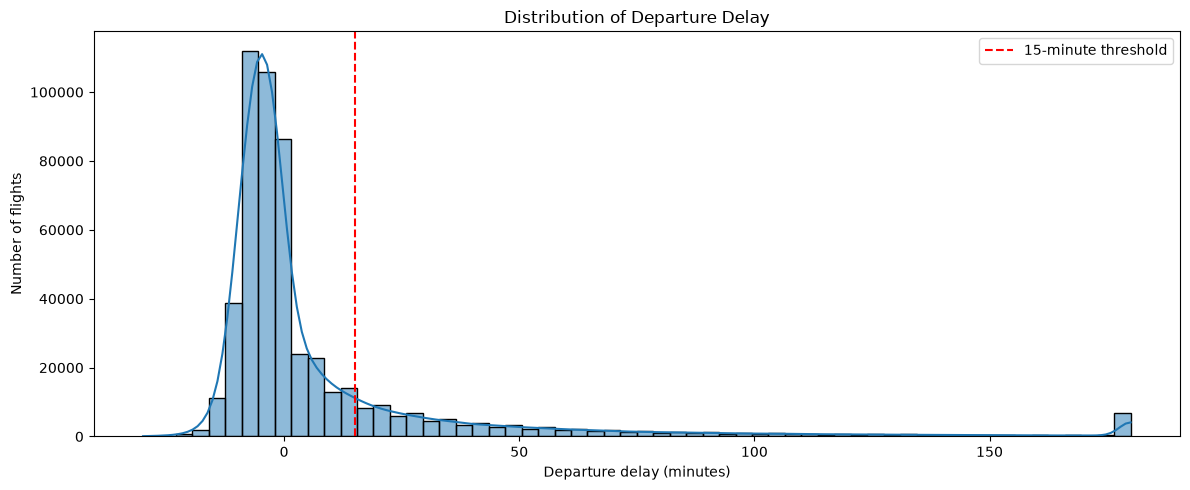

In [3]:
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
missing = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

print(missing)

print("\nTarget distribution:")
print(df["DepDel15"].value_counts(dropna=False))

print("\nTarget percentage:")
print(df["DepDel15"].value_counts(normalize=True, dropna=False))

plt.figure(figsize=(12, 5))

sns.histplot(
    df["DepDelay"].dropna().clip(-30, 180),
    bins=60,
    kde=True
)

plt.axvline(
    15,
    color="red",
    linestyle="--",
    label="15-minute threshold"
)

plt.title("Distribution of Departure Delay")
plt.xlabel("Departure delay (minutes)")
plt.ylabel("Number of flights")
plt.legend()
plt.tight_layout()
plt.show()



Delay rate by airline

In [ ]:
airline_delay = (
    df.groupby("Reporting_Airline")
      .agg(
          flights=("DepDel15", "size"),
          delay_rate=("DepDel15", "mean"),
          avg_delay=("DepDelay", "mean"),
      )
      .sort_values("delay_rate", ascending=False)
)

print(airline_delay)

plt.figure(figsize=(12, 6))

plot_df = airline_delay.reset_index()

sns.barplot(
    data=plot_df,
    x="Reporting_Airline",
    y="delay_rate"
)

plt.axhline(
    df["DepDel15"].mean(),
    color="red",
    linestyle="--",
    label="Overall delay rate"
)

plt.title("15+ Minute Departure Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay rate")
plt.legend()
plt.tight_layout()
plt.show()


Delay rate by departure hour

    DepHour  flights  delay_rate
0         0      572    0.152482
1         1      282    0.180851
2         2       93    0.236559
3         3       56    0.200000
4         4       26    0.360000
5         5    14039    0.089428
6         6    36590    0.080928
7         7    37830    0.100746
8         8    38836    0.119262
9         9    32263    0.144848
10       10    33175    0.168548
11       11    35821    0.181527
12       12    32968    0.196491
13       13    32701    0.201629
14       14    32811    0.215932
15       15    31659    0.221708
16       16    31924    0.222828
17       17    34903    0.223909
18       18    33609    0.231921
19       19    27183    0.241832
20       20    23265    0.250357
21       21    15264    0.244091
22       22    10169    0.227573
23       23     3708    0.165934


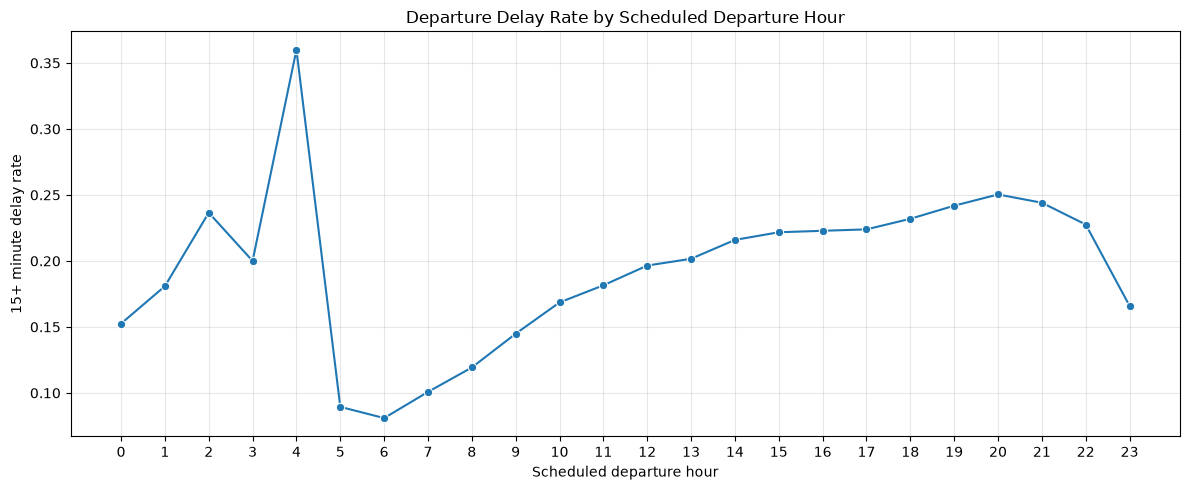

In [4]:
def hhmm_to_hour(value):
    if pd.isna(value):
        return np.nan

    value = int(value)

    return value // 100


df["DepHour"] = df["CRSDepTime"].apply(hhmm_to_hour)

hourly_delay = (
    df.groupby("DepHour")
      .agg(
          flights=("DepDel15", "size"),
          delay_rate=("DepDel15", "mean"),
      )
      .reset_index()
)

print(hourly_delay)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_delay,
    x="DepHour",
    y="delay_rate",
    marker="o"
)

plt.title("Departure Delay Rate by Scheduled Departure Hour")
plt.xlabel("Scheduled departure hour")
plt.ylabel("15+ minute delay rate")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




delay rate by day of week

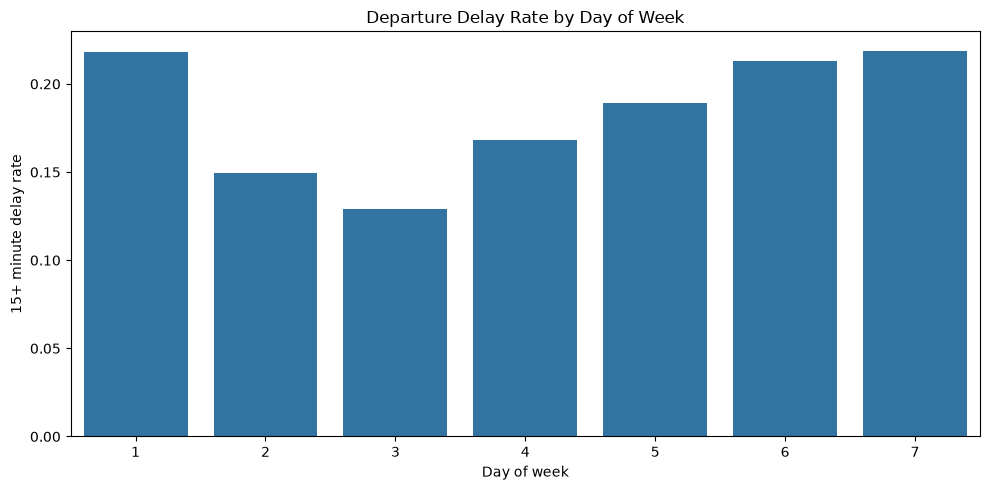

In [5]:
dow_delay = (
    df.groupby("DayOfWeek")
      .agg(
          flights=("DepDel15", "size"),
          delay_rate=("DepDel15", "mean"),
      )
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=dow_delay,
    x="DayOfWeek",
    y="delay_rate"
)

plt.title("Departure Delay Rate by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("15+ minute delay rate")
plt.tight_layout()
plt.show()

#1 = monday

Clean dataset

In [6]:
#select only feature we know beforehand
features = [
    "FlightDate",
    "DayOfWeek",
    "Month",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup",
]

target = "DepDel15"

model_df = df[features + [target]].copy()

#create useful time feature
model_df["FlightDate"] = pd.to_datetime(
    model_df["FlightDate"],
    errors="coerce"
)

model_df["DepHour"] = (
    pd.to_numeric(
        model_df["CRSDepTime"],
        errors="coerce"
    )
    .fillna(-1)
    .astype(int)
    // 100
)

model_df = model_df.drop(columns=["CRSDepTime"])

print("share before clean", model_df.shape)

#remove rows where target is unavailablz
model_df = model_df.dropna(subset=[target])

print("Clean shape:", model_df.shape)

#make sure target is numeric:
model_df[target] = (
    pd.to_numeric(
        model_df[target],
        errors="coerce"
    )
)

model_df = model_df.dropna(subset=[target])

model_df[target] = model_df[target].astype(int)

#sort the data
model_df = model_df.sort_values("FlightDate")

unique_dates = model_df["FlightDate"].drop_duplicates().sort_values()

split_idx = int(len(unique_dates) * 0.8)

train_dates = unique_dates.iloc[:split_idx] #take the oldest ones
test_dates = unique_dates.iloc[split_idx:]

train = model_df[
    model_df["FlightDate"].isin(train_dates)
]

test = model_df[
    model_df["FlightDate"].isin(test_dates)
]

print("Training:", train.shape)
print("Testing :", test.shape)

print(
    "Train dates:",
    train["FlightDate"].min(),
    "→",
    train["FlightDate"].max()
)

print(
    "Test dates:",
    test["FlightDate"].min(),
    "→",
    test["FlightDate"].max()
)




share before clean (539747, 11)
Clean shape: (523824, 11)
Training: (404975, 11)
Testing : (118849, 11)
Train dates: 2025-01-01 00:00:00 → 2025-01-24 00:00:00
Test dates: 2025-01-25 00:00:00 → 2025-01-31 00:00:00


Define X and y

In [7]:
X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

#keep only the day, not the month (as only january)
for data in [X_train, X_test]:

    data["DayOfMonth"] = data["FlightDate"].dt.day
    data["DayOfYear"] = data["FlightDate"].dt.dayofyear

    data.drop(
        columns=["FlightDate"],
        inplace=True
    )


Define features

In [8]:
categorical_features = [
    "Reporting_Airline",
    "Origin",
    "Dest",
]

numeric_features = [
    "DayOfWeek",
    "Month",
    "DayOfMonth",
    "DayOfYear",
    "DepHour",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup",
]


build pipeline

In [12]:
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
    ]
)


Train a simple model

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", model),
    ]
)

pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['DayOfWeek', 'Month',
                                                   'DayOfMonth', 'DayOfYear',
                                                   'DepHour', 'CRSElapsedTime',
                                                   'Distance',
                                                   'DistanceGroup']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Reporting_Airline',
                                                   'Origin', 'Dest'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

evaluate model

In [14]:
y_pred = pipeline.predict(X_test)

y_probability = pipeline.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)


              precision    recall  f1-score   support

           0      0.896     0.838     0.866    105213
           1      0.164     0.246     0.197     13636

    accuracy                          0.770    118849
   macro avg      0.530     0.542     0.531    118849
weighted avg      0.812     0.770     0.789    118849



1. CLASSIFICATION RESULTS
              precision    recall  f1-score   support

     On time      0.896     0.838     0.866    105213
     Delayed      0.164     0.246     0.197     13636

    accuracy                          0.770    118849
   macro avg      0.530     0.542     0.531    118849
weighted avg      0.812     0.770     0.789    118849

2. MODEL QUALITY
ROC-AUC           : 0.583
PR-AUC            : 0.148
Baseline PR-AUC   : 0.115
Actual delay rate : 11.5%
3. CONFUSION MATRIX

                  PREDICTED
                On time  Delayed
ACTUAL On time     TN       FP
       Delayed     FN       TP

[[88163 17050]
 [10285  3351]]


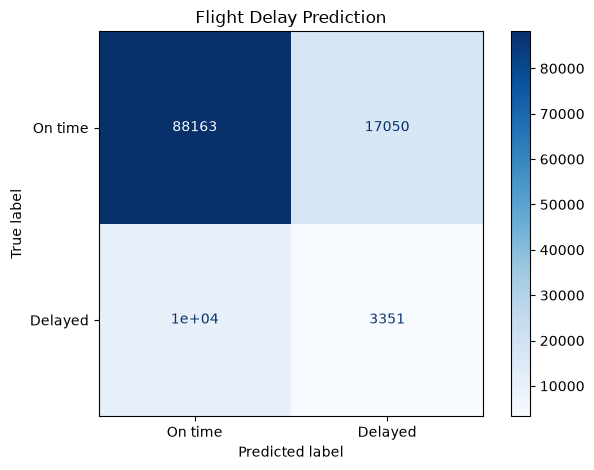

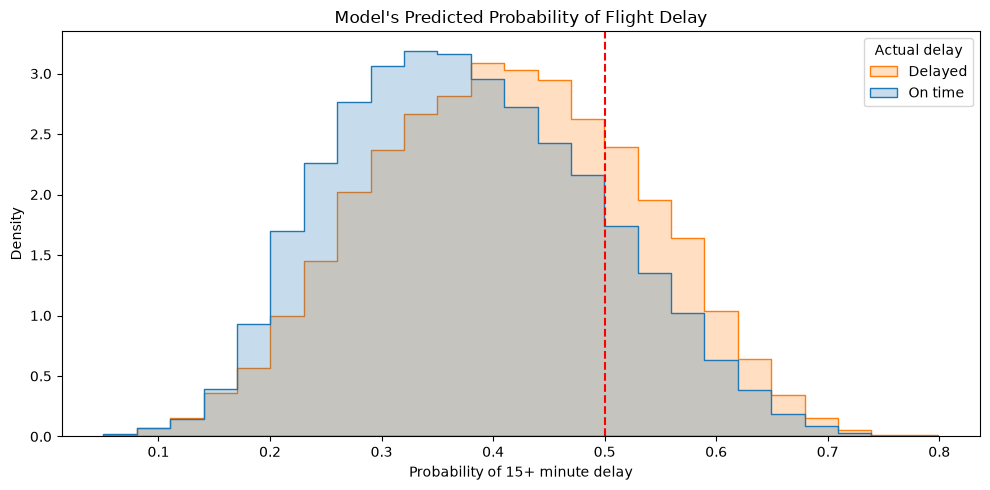

4. QUICK VERDICT
🟡 MAYBE — there is some signal, but it is weak.

Model PR-AUC improvement over baseline: +0.034

WHAT THESE MEAN:
- ROC-AUC: overall ability to distinguish delayed vs on-time flights.
- PR-AUC : quality of finding the relatively rare delayed flights.
- Baseline: how well we do without a useful model.
- Confusion matrix: shows correct and incorrect predictions.

IMPORTANT:
This is only a 1-month PoC. A promising result means
the idea is worth investigating further — NOT that the
model is production-ready.


In [15]:
# ============================================================
# QUICK ML CHECK — Is the flight-delay PoC worth continuing?
# ============================================================

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. BASIC RESULTS
print("=" * 60)
print("1. CLASSIFICATION RESULTS")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred,
    target_names=["On time", "Delayed"],
    digits=3
))

# 2. IMPORTANT SCORES
roc_auc = roc_auc_score(y_test, y_probability)
pr_auc = average_precision_score(y_test, y_probability)

# What percentage of flights were actually delayed?
delay_rate = y_test.mean()

# What would happen if we simply predicted
# the historical average delay probability for every flight?
baseline_pr_auc = average_precision_score(
    y_test,
    np.full(len(y_test), y_train.mean())
)

print("=" * 60)
print("2. MODEL QUALITY")
print("=" * 60)

print(f"ROC-AUC           : {roc_auc:.3f}")
print(f"PR-AUC            : {pr_auc:.3f}")
print(f"Baseline PR-AUC   : {baseline_pr_auc:.3f}")
print(f"Actual delay rate : {delay_rate:.1%}")

# 3. CONFUSION MATRIX
print("=" * 60)
print("3. CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)

print("""
                  PREDICTED
                On time  Delayed
ACTUAL On time     TN       FP
       Delayed     FN       TP
""")

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On time", "Delayed"]
).plot(cmap="Blues")

plt.title("Flight Delay Prediction")
plt.tight_layout()
plt.show()

# 4. PROBABILITY PLOT
results = pd.DataFrame({
    "probability": y_probability,
    "actual": y_test.values
})

plt.figure(figsize=(10, 5))

sns.histplot(
    data=results,
    x="probability",
    hue="actual",
    bins=25,
    stat="density",
    common_norm=False,
    element="step"
)

plt.axvline(
    0.5,
    color="red",
    linestyle="--",
    label="50% decision threshold"
)

plt.title("Model's Predicted Probability of Flight Delay")
plt.xlabel("Probability of 15+ minute delay")
plt.legend(
    title="Actual delay",
    labels=["Delayed", "On time"]
)
plt.tight_layout()
plt.show()

# 5. SIMPLE GO / NO-GO DECISION
print("=" * 60)
print("4. QUICK VERDICT")
print("=" * 60)

improvement = pr_auc - baseline_pr_auc

if improvement < 0.02:
    verdict = "❌ STOP / RETHINK — model has very little useful signal."
elif improvement < 0.05:
    verdict = "🟡 MAYBE — there is some signal, but it is weak."
elif roc_auc >= 0.70:
    verdict = "🟢 CONTINUE — promising signal. Add better features."
else:
    verdict = "🟢 CONTINUE — model has useful predictive signal."

print(verdict)

print(f"\nModel PR-AUC improvement over baseline: {improvement:+.3f}")

print("\nWHAT THESE MEAN:")
print("- ROC-AUC: overall ability to distinguish delayed vs on-time flights.")
print("- PR-AUC : quality of finding the relatively rare delayed flights.")
print("- Baseline: how well we do without a useful model.")
print("- Confusion matrix: shows correct and incorrect predictions.")

print("\nIMPORTANT:")
print("This is only a 1-month PoC. A promising result means")
print("the idea is worth investigating further — NOT that the")
print("model is production-ready.")
